# Embedding Analysis

Embed item titles with SBERT (`all-MiniLM-L6-v2`) and use them to find similar products. Inputs: `data/df_features.pkl` (output of `feature_extraction_workflow/extract_features.ipynb`). Output: `data/df_features_with_embeddings.pkl` (gitignored).

Sections:
1. Load data
2. Generate SBERT embeddings for `title_cleaned`
3. Save the dataframe with embeddings
4. Build the embedding matrix
5. Run each similarity helper on a sample ASIN
6. PCA visualizations

In [89]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

from embedding_analysis import (
    build_matrix,
    create_embeddings,
    get_similar_items_by_category,
    get_similar_items_by_features,
    get_similar_items_diff_cat3,
    get_similar_items_diff_cat4_product_type,
    get_similar_items_same_cat3,
    get_similar_items_same_cat3_diff_cat4,
    get_similar_items_same_cat3_diff_cat4_product_type,
    get_top_n_similar,
    visualize_pca_overall,
    visualize_pca_per_cat2,
)

pd.options.display.max_colwidth = None
pd.options.display.max_columns = None

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load data

Read the feature dataframe produced by `extract_features.ipynb`.

In [4]:
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_PATH = DATA_DIR / 'df_features.pkl'
EMBEDDINGS_PATH = DATA_DIR / 'df_features_with_embeddings.pkl'

df_features = pd.read_pickle(FEATURES_PATH)
print(f'Loaded {len(df_features):,} rows x {df_features.shape[1]} cols from {FEATURES_PATH}')

needed = ['asin', 'title', 'title_cleaned', 'cat_2', 'cat_3', 'cat_4', 'Product_Type']
for col in needed:
    print(f'  {col:20s} present: {col in df_features.columns}')

Loaded 1,134,566 rows x 81 cols from /Users/lazr/PycharmProjects/RecSystem/data/df_features.pkl
  asin                 present: True
  title                present: True
  title_cleaned        present: True
  cat_2                present: True
  cat_3                present: True
  cat_4                present: True
  Product_Type         present: True


In [6]:
# df_emb = pd.read_pickle("/Users/lazr/PycharmProjects/RecSystem/data/df_features_with_embeddings.pkl")
df_emb.shape
df_emb.columns

Index(['category', 'tech1', 'description', 'title', 'tech2', 'brand',
       'feature', 'rank', 'main_cat', 'price', 'asin', 'date', 'cat_1',
       'cat_2', 'cat_3', 'cat_4', 'cat_5', 'cat_6', 'title_cleaned',
       'extracted_features_title', 'description_cleaned',
       'extracted_features_description', 'feature_cleaned',
       'extracted_features_feature', 'extracted_features', 'Bar_Pressure',
       'Brand', 'Capacity', 'Capacity_Cups', 'Capacity_Volume', 'Color',
       'Density_Weight', 'Dimensions', 'Features', 'Filter_Rating', 'Material',
       'Part_Number', 'Piece_Count', 'Pocket_Depth', 'Power_Rating',
       'Product_Type', 'Scent', 'Shape', 'Shape_Style', 'Size', 'Stage_Count',
       'Sub_Type', 'Theme', 'Thread_Count', 'Voltage', 'Weight',
       'capacity_numeric', 'capacity_unit', 'capacity_volume_numeric',
       'capacity_volume_unit', 'piece_count_numeric', 'piece_count_unit',
       'thread_count_numeric', 'thread_count_unit', 'weight_numeric',
       'weight_

## 2. Generate SBERT embeddings

`all-MiniLM-L6-v2` (small SBERT, 384-dim) on `title_cleaned`. Encoding ~1.1M titles on CPU takes a while — set `show_progress_bar=True` to monitor. If `data/df_features_with_embeddings.pkl` already exists, the next cell short-circuits and loads it.

In [ ]:
if EMBEDDINGS_PATH.exists():
    df_emb = pd.read_pickle(EMBEDDINGS_PATH)
    print(f'Loaded existing embeddings from {EMBEDDINGS_PATH}')
    print(f'Shape: {df_emb.shape}')
else:
    df_emb = create_embeddings(
        df_features,
        text_col='title_cleaned',
        model_name='all-MiniLM-L6-v2',
        batch_size=256,
        embedding_col='title_embedding',
    )
    print(f'\nResulting dataframe: {df_emb.shape}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5159.78it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 1,134,566 rows from 'title_cleaned' with all-MiniLM-L6-v2...


Batches:   2%|▏         | 76/4432 [00:21<14:51,  4.88it/s] 

## 3. Save

Persist to `data/df_features_with_embeddings.pkl`. Path is in `.gitignore` so it won't be committed.

In [ ]:
if not EMBEDDINGS_PATH.exists():
    df_emb.to_pickle(EMBEDDINGS_PATH)
    print(f'Saved {len(df_emb):,} rows to {EMBEDDINGS_PATH}')
else:
    print(f'Already exists at {EMBEDDINGS_PATH}; skipping write.')

## 4. Build the embedding matrix

Stack the embedding column into a 2D array. `all-MiniLM-L6-v2` already returns unit-norm vectors, so cosine similarity reduces to a plain dot product — no extra normalization step needed. `asins` is a parallel array used by every helper to look up rows by ASIN.

In [7]:
matrix, asins = build_matrix(df_emb, embedding_col='title_embedding')
print(f'matrix shape     : {matrix.shape}')
print(f'asins length     : {len(asins):,}')
print(f'first row L2 norm: {np.linalg.norm(matrix[0]):.4f} (should be 1.0)')

matrix shape     : (1134566, 384)
asins length     : 1,134,566
first row L2 norm: 1.0000 (should be 1.0)


## 5. Similarity helpers

Each helper takes one query ASIN, scores it against the whole matrix (or a category-filtered subset), and returns the top-N as a small dataframe. Replace `QUERY_ASIN` with any ASIN present in `asins`.

In [75]:
QUERY_ASIN = 'B01HJCG0RS'   # same example used in analyze_features_eda.ipynb
N = 10

if QUERY_ASIN not in set(asins):
    QUERY_ASIN = asins[0]
    print(f'Default ASIN not in this dataset; falling back to first row: {QUERY_ASIN}')
else:
    print(f'Using query ASIN: {QUERY_ASIN}')

Using query ASIN: B01HJCG0RS


In [76]:
pd.set_option('display.max_colwidth', 300)
df_emb[df_emb['asin'] == QUERY_ASIN]

,category,tech1,description,title,tech2,brand,feature,rank,main_cat,price,asin,date,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,title_cleaned,extracted_features_title,description_cleaned,extracted_features_description,feature_cleaned,extracted_features_feature,extracted_features,Bar_Pressure,Brand,Capacity,Capacity_Cups,Capacity_Volume,Color,Density_Weight,Dimensions,Features,Filter_Rating,Material,Part_Number,Piece_Count,Pocket_Depth,Power_Rating,Product_Type,Scent,Shape,Shape_Style,Size,Stage_Count,Sub_Type,Theme,Thread_Count,Voltage,Weight,capacity_numeric,capacity_unit,capacity_volume_numeric,capacity_volume_unit,piece_count_numeric,piece_count_unit,thread_count_numeric,thread_count_unit,weight_numeric,weight_unit,bar_pressure_numeric,capacity_cups_numeric,density_weight_lb,pocket_depth_in,power_rating_w,stage_count_numeric,voltage_numeric,dimension_1,dimension_2,dimension_3,dimension_unit,bar_pressure_numeric_cleaned,capacity_cups_numeric_cleaned,density_weight_lb_cleaned,pocket_depth_in_cleaned,power_rating_w_cleaned,stage_count_numeric_cleaned,voltage_numeric_cleaned,thread_count_numeric_cleaned,weight_numeric_cleaned,title_embedding,imageURL,imageURLHighRes
1134521,"['Home & Kitchen', 'Furniture', 'Kitchen & Dining Room Furniture', 'Chairs']","class=""a-keyvalue prodDetTable"" role=""presentation"">\n \n \n \n \n <tr>\n \n \n \n \n \n <th class=""a-color-secondary a-size-base prodDetSectionEntry"">\n ...",['<BR>High Quality Product Can Withstand 250 lbs <BR>The retro simplicity of these classic white accent chairs will instantly enhance the modernity of your room. <BR>Each of these contemporary accent chairs is made from durable matte-finish molded plastic with an ergonomically-shaped and curved ...,"Set of Four White New Seat Height 18.5 inches Chair White Wood Legs for Dining Room Armless Chairs,White",NaN,beauty inc,"['Set of 4 Eames Style Side Chairs / Accent Seats - Natural Wood Legs - High Quality Dining Room Chairs', 'Heavy-duty molded contemporary plastic seat (matte finish)', 'Straight wooden dowel legs w/ floor protectors for sensitive flooring', 'Ergonomically shaped & comfortable curved seating - Gr...","['>#5,036,688 in Home & Kitchen (See top 100)', '>#7,175 in Home & Kitchen > Furniture > Kitchen & Dining Room Furniture > Chairs']",Amazon Home,NaN,B01HJCG0RS,"June 25, 2016",Home & Kitchen,Furniture,Kitchen & Dining Room Furniture,Chairs,None,None,set 4 white seat height 18.5 inch chair white wood leg dining room armless chair white,"{'Color': 'white', 'Dimensions': '5 inch', 'Piece_Count': 'set 4'}",br high quality product withstand 250 lb br retro simplicity classic white accent chair instantly enhance modernity room br contemporary accent chair made durable matte-finish molded plastic ergonomically-shaped curved seat br leg wooden include steel hardware black well black plastic tip protec...,"{'Product_Type': 'accent chair', 'Material': 'plastic', 'Color': 'black', 'Features': 'contemporary', 'Dimensions': '5 inch', 'Piece_Count': 'set 4'}",set 4 eames style side chair accent seat - natural wood leg - high quality dining room chair heavy-duty molded contemporary plastic seat matte finish straight wooden dowel leg w floor protector sensitive flooring ergonomically shaped comfortable curved seating - great office use - living room di...,"{'Product_Type': 'side chair', 'Material': 'hardwood', 'Color': 'natural', 'Features': 'contemporary', 'Piece_Count': 'set 4'}","{'Product_Type': 'accent chair', 'Material': 'plastic', 'Color': 'white', 'Features': 'contemporary', 'Piece_Count': 'set 4', 'Dimensions': '5 inch'}",None,None,None,None,None,white,None,5 inch,contemporary,None,plastic,None,set 4,None,None,accent chair,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,in,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.11431968, 0.115466215, 0.0022110662, -0.025600743, -0.10875601, 0.04891194, -0.08009628, 0.0060809134, 0.019391805, -0.008444323, 0

In [84]:
df_emb.iloc[1134521]['imageURLHighRes']

"['https://images-na.ssl-images-amazon.com/images/I/41%2Bc%2BYQTVPL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41QkTrp4dlL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41PaGDYwfOL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL.jpg']"

In [74]:
# df_emb[df_emb['cat_2'] == 'Furniture']

### Attach image URLs

Bring `imageURL` and `imageURLHighRes` from `meta_Home_and_Kitchen_filtered.csv` onto `df_emb` so the similarity helpers can surface them. Joined on `asin`; missing rows become `NaN`.

In [8]:
# Join imageURL / imageURLHighRes from the raw filtered metadata onto df_emb
# so the similarity helpers can return them alongside titles and categories.


# _meta_images = pd.read_csv(
#     DATA_DIR / 'meta_Home_and_Kitchen_filtered.csv',
#     usecols=['asin', 'imageURL', 'imageURLHighRes'],
#     low_memory=False,
# ).drop_duplicates(subset='asin')
#
# df_emb = df_emb.merge(_meta_images, on='asin', how='left')
# print(f'df_emb shape after image join: {df_emb.shape}')
# print(f'rows with imageURL:        {df_emb["imageURL"].notna().sum():,}')
# print(f'rows with imageURLHighRes: {df_emb["imageURLHighRes"].notna().sum():,}')

df_emb shape after image join: (1134566, 84)
rows with imageURL:        1,134,566
rows with imageURLHighRes: 1,134,566


In [80]:
# 5.1 Plain top-N (no filter, no boost)
get_top_n_similar(QUERY_ASIN, df_emb, matrix, asins, n=N)['imageURLHighRes']

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS



0                                                                                                 ['https://images-na.ssl-images-amazon.com/images/I/41%2BGJu2RGXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41pEHj1lcBL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL.jpg']
1                                                                                                   ['https://images-na.ssl-images-amazon.com/images/I/31H4QtzrOPL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31J3aYL98SL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31sW-sDlrWL.jpg']
2                                                                                                                                                                                                                                                                                                             []
3    ['https://images-na.ssl-images-amazon.com/images/I/5130HUTAGlL.jpg', 'https://im

In [83]:
# 5.2 Top-N with cat_3 (+0.10) and cat_4 (+0.05) score boosts
pd.set_option('display.max_colwidth', 300)
get_similar_items_by_category(QUERY_ASIN, df_emb, matrix, asins, n=N)['imageURLHighRes']

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS
cat_3: Kitchen & Dining Room Furniture | cat_4: Chairs



0                                                                                                 ['https://images-na.ssl-images-amazon.com/images/I/41%2BGJu2RGXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41pEHj1lcBL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL.jpg']
1                                                                                                   ['https://images-na.ssl-images-amazon.com/images/I/31H4QtzrOPL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31J3aYL98SL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31sW-sDlrWL.jpg']
2                                                                                                                                                                                                                                                                                                             []
3    ['https://images-na.ssl-images-amazon.com/images/I/5130HUTAGlL.jpg', 'https://im

In [85]:
# 5.3 Restricted to the same cat_3 as the query
get_similar_items_same_cat3(QUERY_ASIN, df_emb, matrix, asins, n=N)

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS | cat_3: Kitchen & Dining Room Furniture
Same-category items: 7,668



,asin,similarity,title,title_cleaned,cat_3,cat_4,brand,extracted_features,imageURL,imageURLHighRes
0,B01HEF0UGM,0.9908,Set of Four White New Seat Height 18.5 inches Chair White Wood Legs for Dining Room Armless Chairs,set 4 white seat height 18.5 inch chair white wood leg dining room armless chair,Kitchen & Dining Room Furniture,Chairs,beauty inc,"{'Product_Type': 'accent chair', 'Material': 'plastic', 'Color': 'white', 'Features': 'contemporary', 'Piece_Count': 'set 4', 'Dimensions': '5 inch'}","['https://images-na.ssl-images-amazon.com/images/I/41%2BGJu2RGXL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41pEHj1lcBL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/41%2BGJu2RGXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41pEHj1lcBL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL.jpg']"
1,B00G4SY95O,0.7446,*Set of 4* High Quality Eames Style DSW Dining Side Chair - White,set 4 high quality eames style dsw dining side chair - white,Kitchen & Dining Room Furniture,Chairs,NaN,"{'Product_Type': 'side chair', 'Color': 'white', 'Piece_Count': 'set 4'}","['https://images-na.ssl-images-amazon.com/images/I/31H4QtzrOPL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31J3aYL98SL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31sW-sDlrWL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/31H4QtzrOPL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31J3aYL98SL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31sW-sDlrWL.jpg']"
2,B000A3PKX4,0.7418,Set of 4 Natural &amp; White Finish Windsor Wood Dining Chair/Chairs,set 4 natural white finish windsor wood dining chair chair,Kitchen & Dining Room Furniture,Chairs,Acme Furniture,"{'Product_Type': 'dining chair', 'Material': 'hardwood', 'Color': 'natural', 'Piece_Count': 'set 4'}",[],[]
3,B01F8PU3A8,0.7181,"ELERANBE Set of 4 Eames DSW Style Side 18&quot; Height Armless Accent Chairs with Eiffel Natural Beech Wood Base Legs for Dining Waiting Room Bedroom Kitchen, White",eleranbe set 4 eames dsw style side 18 height armless accent chair eiffel natural beech wood base leg dining waiting room bedroom white,Kitchen & Dining Room Furniture,Chairs,ELERANBE,"{'Product_Type': 'accent chair', 'Material': 'plastic', 'Color': 'natural', 'Features': 'modern', 'Dimensions': '32 inch', 'Piece_Count': 'set 4'}","['https://images-na.ssl-images-amazon.com/images/I/5130HUTAGlL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51QTXTjQNrL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51nnYf7ttSL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51z7A6bwSaL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/5130HUTAGlL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51QTXTjQNrL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51nnYf7ttSL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51z7A6bwSaL.jpg', 'https://images-na.ssl-..."
4,B00OSK160G,0.7148,Set of 4 Dark Oak Wood Dining Chairs,set 4 dark oak wood dining chair,Kitchen & Dining Room Furniture,Chairs,Home Accent Furnishings,"{'Material': 'oak', 'Color': 'oak', 'Piece_Count': 'set 4', 'Product_Type': 'dining chair'}","['https://images-na.ssl-images-amazon.com/images/I/51TKlp0th%2BL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51EcWH5AkwL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/51TKlp0th%2BL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51EcWH5AkwL.jpg']"
5,B00G4T1OL0,0.7072,*Set of 6* High Quality Eames Style DSW Dining Side Chair - White,set 6 high quality eames style dsw dining side chair - white,Kitchen & Dining Room Furniture,Chairs,NaN,"{'Product_Type': 'side chair', 'Color': 'white', 'Piece_Count': 'set 6'}","['https://images-na.ssl-images-amazon.com/images/I/31H4QtzrOPL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com

In [86]:
# 5.4 Same cat_3, different cat_4
get_similar_items_same_cat3_diff_cat4(QUERY_ASIN, df_emb, matrix, asins, n=N)

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS | cat_3: Kitchen & Dining Room Furniture | cat_4: Chairs
Same cat_3, different cat_4 items: 4,522



,asin,similarity,title,title_cleaned,cat_3,cat_4,brand,extracted_features,imageURL,imageURLHighRes
0,B00529PAAO,0.6861,Dining Room Set (Table + 4 Chairs),dining room set table 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,HI,"{'Product_Type': 'dining table', 'Material': 'mahogany', 'Color': 'cappuccino', 'Piece_Count': '4 chair'}","['https://images-na.ssl-images-amazon.com/images/I/41O9Ck7u0eL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/41O9Ck7u0eL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL.jpg']"
1,B0052F60AC,0.6861,Dining Room Set (Table + 4 Chairs),dining room set table 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,HI,"{'Product_Type': 'dining table', 'Material': 'mahogany', 'Color': 'cappuccino', 'Piece_Count': '4 chair'}","['https://images-na.ssl-images-amazon.com/images/I/41MzqRz90iL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/41MzqRz90iL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL.jpg']"
2,B005F69NJI,0.6403,Ikea Table and 2 Chairs Set White Dining Kitchen Modern,ikea table 2 chair set white dining modern,Kitchen & Dining Room Furniture,Table & Chair Sets,NaN,"{'Color': 'white', 'Features': 'modern', 'Piece_Count': '2 chair'}",['https://images-na.ssl-images-amazon.com/images/I/41SW8N0DJZL._SS40_.jpg'],['https://images-na.ssl-images-amazon.com/images/I/41SW8N0DJZL.jpg']
3,B00FZS8F9A,0.6297,Standard Furniture 18282 Brooklyn Dining Room Set with a Table and Six Chairs in White,standard furniture 18282 brooklyn dining room set table 6 chair white,Kitchen & Dining Room Furniture,Table & Chair Sets,Standard Furniture,"{'Material': 'hardwood', 'Color': 'white', 'Features': 'counter height', 'Shape': 'square', 'Product_Type': 'dining table', 'Piece_Count': '6 chair'}",[],[]
4,B001F0TBX6,0.6256,Oval Dining Room Wood Table Chair Set Kitchen Chairs,oval dining room wood table chair set chair,Kitchen & Dining Room Furniture,Table & Chair Sets,Coaster Home Furnishings,"{'Product_Type': 'dining chair', 'Piece_Count': '7 piece', 'Material': 'solid wood', 'Color': 'cappuccino', 'Features': 'contemporary', 'Shape': 'oval'}",[],[]
5,B001LV6GX2,0.6234,5pcs Retro White Round Dining Table &amp; 4 White Chairs Set,5pcs retro white round dining table 4 white chair set,Kitchen & Dining Room Furniture,Table & Chair Sets,Coaster Home Furnishings,"{'Product_Type': 'dining table', 'Material': 'chrome', 'Color': 'white', 'Piece_Count': '5pc', 'Shape': 'round', 'Dimensions': '17 x 35'}",[],[]
6,B008W1F1BC,0.6210,FORMAL DINING ROOM TABLE LUGANO 5 PIECE SET 4 CHAIRS,formal dining room table lugano 5 piece set 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,NaN,"{'Product_Type': 'dining table', 'Features': 'storage', 'Dimensions': '52 x 18 x 33', 'Piece_Count': '5 piece'}",[],[]
7,B00DVG9T20,0.6153,"CorLiving DTC-614-T Kitchen Set with 4 Chairs, Soft White Wash Finish",corliving dtc-614-t set 4 chair soft white wash finish,Kitchen & Dining Room Furniture,Table & Chair Sets,CorLiving,"{'Material': 'solid wood', 'Color': 'white', 'Piece_Count': 'set 4'}","['https://images-na.ssl-images-amazon.com/images/I/51sAwbxizKL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rWVbkph-L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/314MmCbGSbL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rLfj6dLqL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/51sAwbxizKL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rWVbkph-L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/314MmCbGSbL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rLfj6dLqL.jpg', 'https://images-na.ssl-..."
8,B005925RDY,0.6146,"Standard Furniture Pendwood Counter Height Table &amp; Four Chairs Set, Dark Cherry Brown",standard furniture pendw

In [87]:
# 5.5 Same cat_3, different cat_4 AND different Product_Type
get_similar_items_same_cat3_diff_cat4_product_type(QUERY_ASIN, df_emb, matrix, asins, n=N)

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS | cat_3: Kitchen & Dining Room Furniture | cat_4: Chairs | Product_Type: accent chair
Same cat_3, different cat_4 & Product_Type items: 4,515



,asin,similarity,title,title_cleaned,cat_3,cat_4,Product_Type,brand,extracted_features,imageURL,imageURLHighRes
0,B0052F60AC,0.6861,Dining Room Set (Table + 4 Chairs),dining room set table 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,dining table,HI,"{'Product_Type': 'dining table', 'Material': 'mahogany', 'Color': 'cappuccino', 'Piece_Count': '4 chair'}","['https://images-na.ssl-images-amazon.com/images/I/41MzqRz90iL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/41MzqRz90iL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL.jpg']"
1,B00529PAAO,0.6861,Dining Room Set (Table + 4 Chairs),dining room set table 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,dining table,HI,"{'Product_Type': 'dining table', 'Material': 'mahogany', 'Color': 'cappuccino', 'Piece_Count': '4 chair'}","['https://images-na.ssl-images-amazon.com/images/I/41O9Ck7u0eL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL._SS40_.jpg']","['https://images-na.ssl-images-amazon.com/images/I/41O9Ck7u0eL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41XoTEdWsnL.jpg']"
2,B005F69NJI,0.6403,Ikea Table and 2 Chairs Set White Dining Kitchen Modern,ikea table 2 chair set white dining modern,Kitchen & Dining Room Furniture,Table & Chair Sets,None,NaN,"{'Color': 'white', 'Features': 'modern', 'Piece_Count': '2 chair'}",['https://images-na.ssl-images-amazon.com/images/I/41SW8N0DJZL._SS40_.jpg'],['https://images-na.ssl-images-amazon.com/images/I/41SW8N0DJZL.jpg']
3,B00FZS8F9A,0.6297,Standard Furniture 18282 Brooklyn Dining Room Set with a Table and Six Chairs in White,standard furniture 18282 brooklyn dining room set table 6 chair white,Kitchen & Dining Room Furniture,Table & Chair Sets,dining table,Standard Furniture,"{'Material': 'hardwood', 'Color': 'white', 'Features': 'counter height', 'Shape': 'square', 'Product_Type': 'dining table', 'Piece_Count': '6 chair'}",[],[]
4,B001F0TBX6,0.6256,Oval Dining Room Wood Table Chair Set Kitchen Chairs,oval dining room wood table chair set chair,Kitchen & Dining Room Furniture,Table & Chair Sets,dining chair,Coaster Home Furnishings,"{'Product_Type': 'dining chair', 'Piece_Count': '7 piece', 'Material': 'solid wood', 'Color': 'cappuccino', 'Features': 'contemporary', 'Shape': 'oval'}",[],[]
5,B001LV6GX2,0.6234,5pcs Retro White Round Dining Table &amp; 4 White Chairs Set,5pcs retro white round dining table 4 white chair set,Kitchen & Dining Room Furniture,Table & Chair Sets,dining table,Coaster Home Furnishings,"{'Product_Type': 'dining table', 'Material': 'chrome', 'Color': 'white', 'Piece_Count': '5pc', 'Shape': 'round', 'Dimensions': '17 x 35'}",[],[]
6,B008W1F1BC,0.6210,FORMAL DINING ROOM TABLE LUGANO 5 PIECE SET 4 CHAIRS,formal dining room table lugano 5 piece set 4 chair,Kitchen & Dining Room Furniture,Table & Chair Sets,dining table,NaN,"{'Product_Type': 'dining table', 'Features': 'storage', 'Dimensions': '52 x 18 x 33', 'Piece_Count': '5 piece'}",[],[]
7,B00DVG9T20,0.6153,"CorLiving DTC-614-T Kitchen Set with 4 Chairs, Soft White Wash Finish",corliving dtc-614-t set 4 chair soft white wash finish,Kitchen & Dining Room Furniture,Table & Chair Sets,None,CorLiving,"{'Material': 'solid wood', 'Color': 'white', 'Piece_Count': 'set 4'}","['https://images-na.ssl-images-amazon.com/images/I/51sAwbxizKL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rWVbkph-L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/314MmCbGSbL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rLfj6dLqL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/51sAwbxizKL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rWVbkph-L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/314MmCbGSbL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31rLfj6dLqL.jpg', 'https://images-na.ssl-..."
8,B005925RDY,0.6146,"Standard Furni

In [24]:
# 5.6 Different cat_4 AND different Product_Type (any cat_3)
get_similar_items_diff_cat4_product_type(QUERY_ASIN, df_emb, matrix, asins, n=N)

Query: style 5004-41 4 drawer americana chest distressed oak
ASIN:  B00UW1U5LQ | cat_4: Dressers | Product_Type: chest
Different cat_4 & Product_Type items: 1,132,741



,asin,similarity,title,title_cleaned,cat_3,cat_4,Product_Type,brand,extracted_features,imageURL,imageURLHighRes
0,B00UW1UFFC,0.8282,"Home Styles 5003-500 Americana Bed, Queen, Black and Distressed Oak",style 5003-500 americana bed queen black distressed oak,Bedroom Furniture,"Beds, Frames & Bases",bed,Home Styles,"{'Color': 'black', 'Product_Type': 'bed', 'Material': 'oak', 'Features': 'rustic', 'Size': 'queen'}",['https://images-na.ssl-images-amazon.com/images/I/613zzBngCeL._SS40_.jpg'],['https://images-na.ssl-images-amazon.com/images/I/613zzBngCeL.jpg']
1,B00UW1TJHC,0.8138,"Home Styles 5003-72 Americana Vanity and Bench, Black and Distressed Oak",style 5003-72 americana vanity bench black distressed oak,Bedroom Furniture,Vanities & Vanity Benches,vanity,Home Styles,"{'Color': 'black', 'Product_Type': 'vanity', 'Material': 'oak', 'Features': 'upholstered'}",['https://images-na.ssl-images-amazon.com/images/I/61Acu4C%2BxpL._SS40_.jpg'],['https://images-na.ssl-images-amazon.com/images/I/61Acu4C%2BxpL.jpg']
2,B003HBUDME,0.8120,"Home Styles 5004-69 Americana Pantry Storage Cabinet, Distressed Oak Finish",style 5004-69 americana pantry storage cabinet distressed oak finish,Kitchen & Dining Room Furniture,Pantries,None,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Features': 'storage', 'Dimensions': '30 inch'}","['https://images-na.ssl-images-amazon.com/images/I/517Actb801L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51L8OKUkZxL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41KHf3NXJuL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41uHYz-m4LL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/517Actb801L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51L8OKUkZxL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41KHf3NXJuL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41uHYz-m4LL.jpg', 'https://images-na.ssl-..."
3,B003ISJ4L2,0.7985,"Home Styles 5004-94 Kitchen Island, Distressed Oak Finish",style 5004-94 island distressed oak finish,Kitchen & Dining Room Furniture,Kitchen Islands & Carts,stool,Home Styles,"{'Product_Type': 'stool', 'Material': 'oak', 'Color': 'oak', 'Features': 'drop leaf', 'Dimensions': '2 inch'}","['https://images-na.ssl-images-amazon.com/images/I/51uDmnSplXL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61qGwOQrZgL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61E0CpoG52L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51mJJXRwXWL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/51uDmnSplXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61qGwOQrZgL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61E0CpoG52L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51mJJXRwXWL.jpg', 'https://images-na.ssl-..."
4,B0035ZIDEC,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,None,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
5,B003M9KYSY,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,None,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
6,B0025TWMSM,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,None,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
7,B0014ZQJSC,0.7750,"Home Styles 5527-19 Homestead Compact Office Cabinet, Distressed Warm Oak Finish",style 5527-19 homestead compact office cabinet distresse

In [25]:
# 5.7 Items NOT in the same cat_3 as the query
get_similar_items_diff_cat3(QUERY_ASIN, df_emb, matrix, asins, n=N)

Query: style 5004-41 4 drawer americana chest distressed oak
ASIN:  B00UW1U5LQ | cat_3: Bedroom Furniture
Different-category items: 1,121,385



,asin,similarity,title,title_cleaned,cat_3,cat_4,brand,extracted_features,imageURL,imageURLHighRes
0,B003HBUDME,0.8120,"Home Styles 5004-69 Americana Pantry Storage Cabinet, Distressed Oak Finish",style 5004-69 americana pantry storage cabinet distressed oak finish,Kitchen & Dining Room Furniture,Pantries,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Features': 'storage', 'Dimensions': '30 inch'}","['https://images-na.ssl-images-amazon.com/images/I/517Actb801L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51L8OKUkZxL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41KHf3NXJuL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41uHYz-m4LL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/517Actb801L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51L8OKUkZxL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41KHf3NXJuL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41uHYz-m4LL.jpg', 'https://images-na.ssl-..."
1,B003ISJ4L2,0.7985,"Home Styles 5004-94 Kitchen Island, Distressed Oak Finish",style 5004-94 island distressed oak finish,Kitchen & Dining Room Furniture,Kitchen Islands & Carts,Home Styles,"{'Product_Type': 'stool', 'Material': 'oak', 'Color': 'oak', 'Features': 'drop leaf', 'Dimensions': '2 inch'}","['https://images-na.ssl-images-amazon.com/images/I/51uDmnSplXL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61qGwOQrZgL._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61E0CpoG52L._SS40_.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51mJJXRwXWL._SS40_.j...","['https://images-na.ssl-images-amazon.com/images/I/51uDmnSplXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61qGwOQrZgL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/61E0CpoG52L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/51mJJXRwXWL.jpg', 'https://images-na.ssl-..."
2,B0035ZIDEC,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
3,B003M9KYSY,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
4,B0025TWMSM,0.7931,"Home Styles 5538-19 Country Casual Compact Office Cabinet, Distressed Oak Finish",style 5538-19 country casual compact office cabinet distressed oak finish,Home Office Furniture,Home Office Cabinets,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'adjustable'}",[],[]
5,B0014ZQJSC,0.7750,"Home Styles 5527-19 Homestead Compact Office Cabinet, Distressed Warm Oak Finish",style 5527-19 homestead compact office cabinet distressed warm oak finish,Home Office Furniture,Home Office Cabinets,Home Styles,"{'Material': 'oak', 'Color': 'oak', 'Dimensions': '4 inch', 'Features': 'keyboard tray'}",[],[]
6,B00UW1SUOU,0.7596,"Home Styles 5003-349 7-Piece Americana Dining Set, Black and Oak",style 5003-349 7 piece americana dining set black oak,Kitchen & Dining Room Furniture,Table & Chair Sets,Home Styles,"{'Color': 'black', 'Dimensions': '18 inch', 'Product_Type': 'dining table', 'Material': 'oak', 'Features': 'rustic', 'Piece_Count': '7 piece'}",['https://images-na.ssl-images-amazon.com/images/I/616f0sPgHLL._SS40_.jpg'],['https://images-na.ssl-images-amazon.com/images/I/616f0sPgHLL.jpg']
7,B007L7746I,0.7568,"Home Styles Deluxe Traditions Island Furniture, White and Distressed Oak Finish",style deluxe tradition island furniture white distressed oak finish,Kitchen & Dining Room Furniture,Kitchen Islands & Carts,Home Styles,"{'Color': 'white', 'Features': 'drop leaf', 

### 5.8 Feature-based filter (Product_Type, Material, Color)

Keep candidates whose `Product_Type` matches the query (or is missing on the candidate), `Material` matches (or is missing on the candidate), and `Color` matches exactly. Filters where the query's own value is missing get skipped.

In [91]:
# 5.8 Same Product_Type (or missing), same Material (or missing), same Color
get_similar_items_by_features(QUERY_ASIN, df_emb, matrix, asins, n=N)['imageURLHighRes']

Query: set 4 white seat height 18.5 inch chair white wood leg dining room armless chair
ASIN:  B01HJCG0RS
Product_Type: accent chair | Material: plastic | Color: white
Matching items: 11,236



0                                                                      ['https://images-na.ssl-images-amazon.com/images/I/41%2BGJu2RGXL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41pEHj1lcBL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/411uEFAiEWL.jpg']
1                                                                                                                                                                                                                ['https://images-na.ssl-images-amazon.com/images/I/41SW8N0DJZL.jpg']
2    ['https://images-na.ssl-images-amazon.com/images/I/31xfV89uslL.jpg', 'https://images-na.ssl-images-amazon.com/images/I/31fZETXwz9L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41WFX6PKL2L.jpg', 'https://images-na.ssl-images-amazon.com/images/I/41CwZmtrZ-L.jpg']
3                                                                                                                                                                     

## 6. PCA visualizations

Reduce the 384-dim embeddings to 2D and scatter colored by category. The overall view captures cat_2-level separation; the per-cat_2 views zoom into one group at a time and color by cat_3.

**Heads up**: PCA on a ~1M × 384 matrix takes a minute or so, and rendering ~1M scatter points is heavy. If you're iterating, sample the dataframe first (e.g. `df_sample = df_emb.sample(50_000, random_state=42)` then rebuild the matrix on the sample).

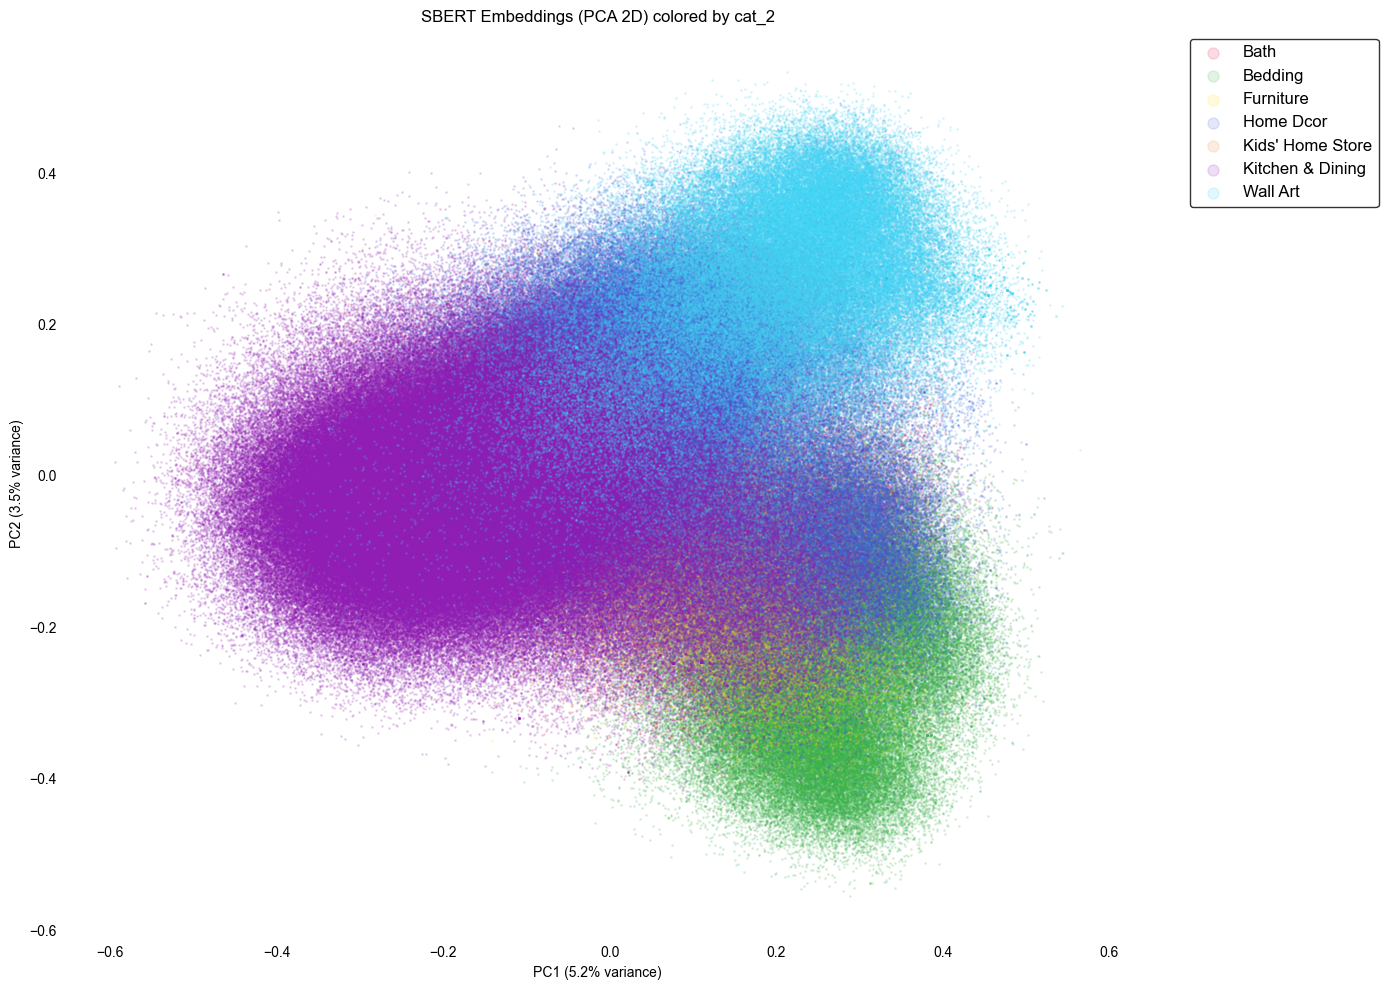

In [18]:
# 6.1 Overall PCA, colored by cat_2
visualize_pca_overall(matrix, df_emb, color_by='cat_2')

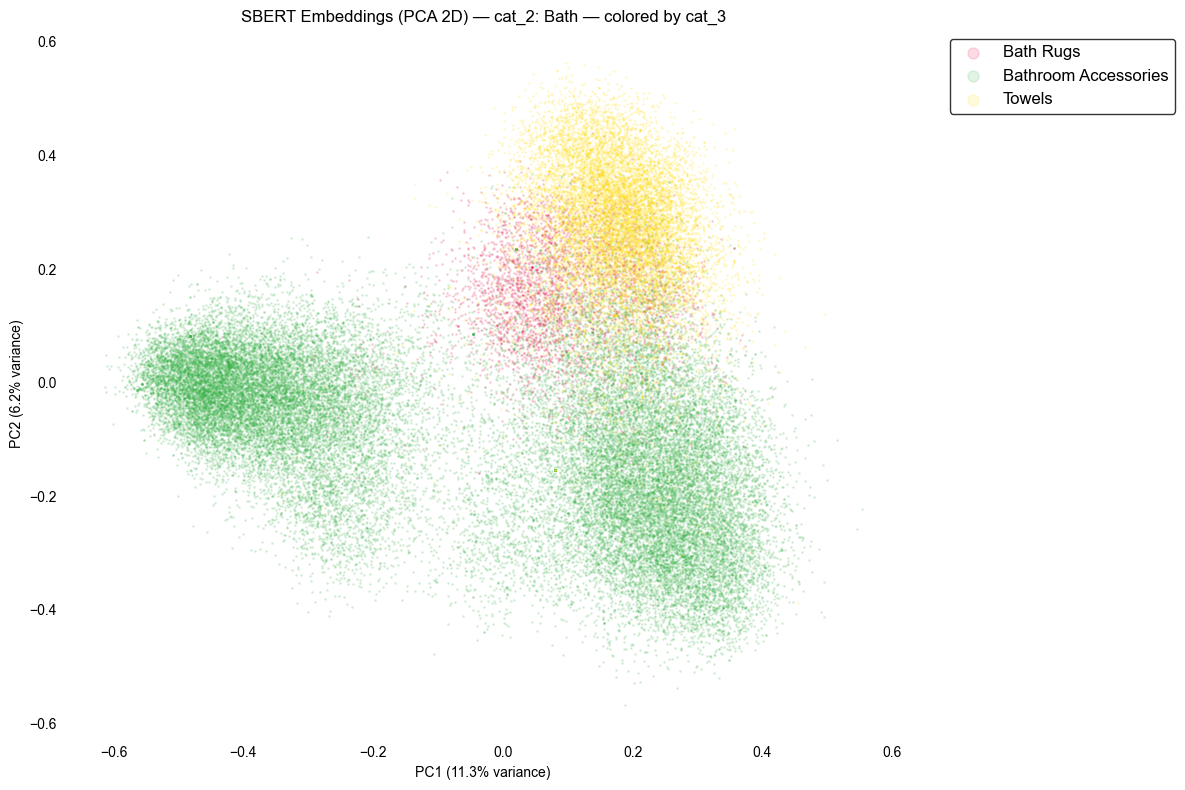

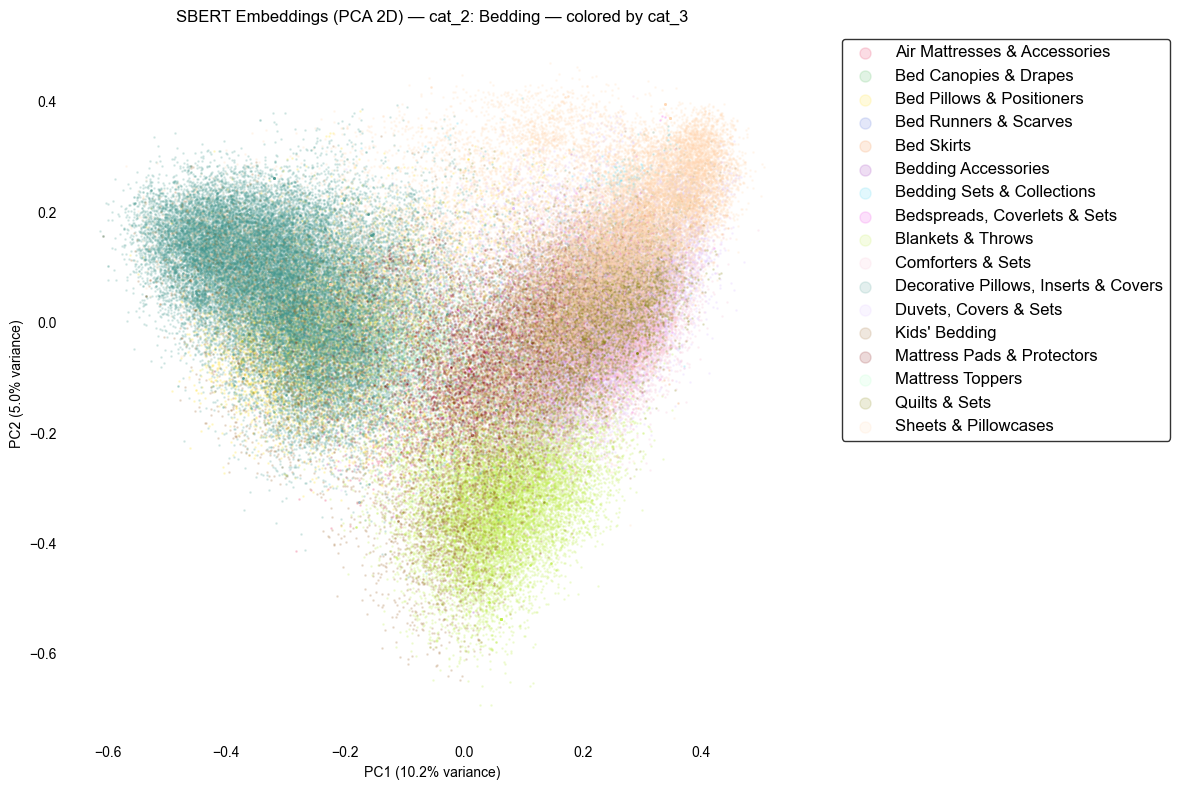

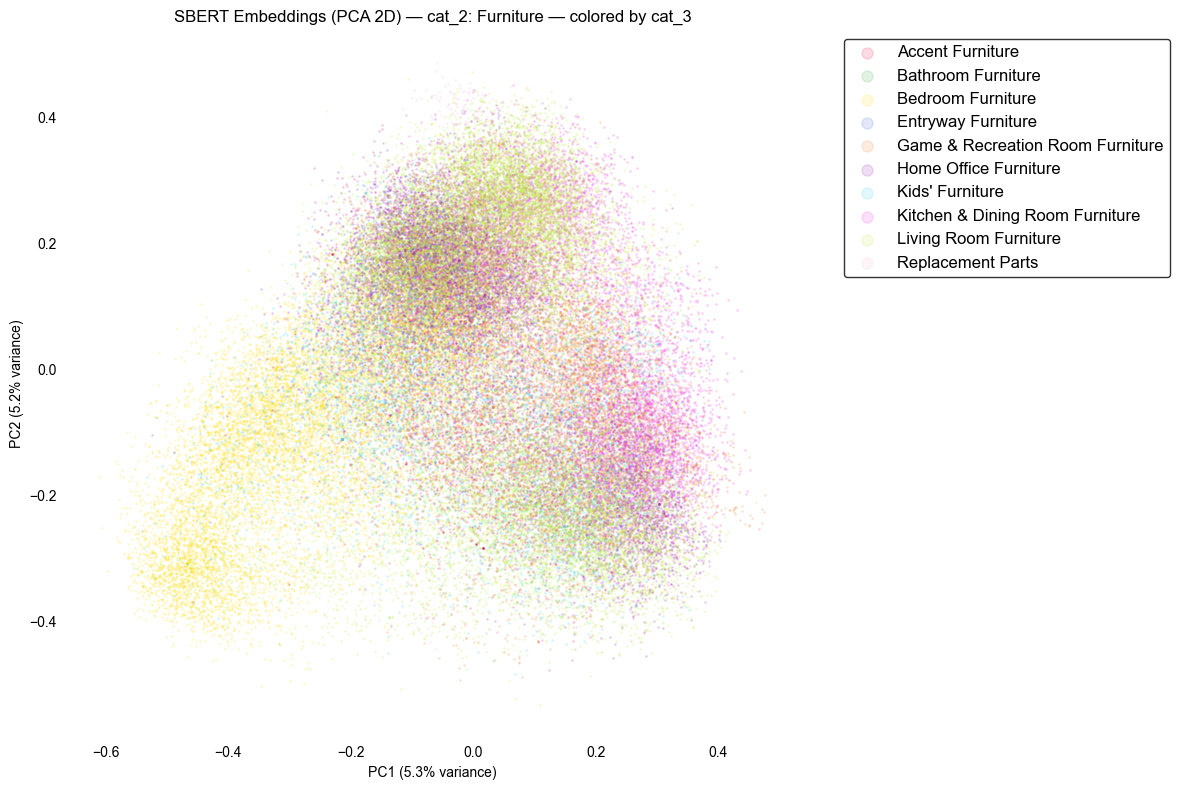

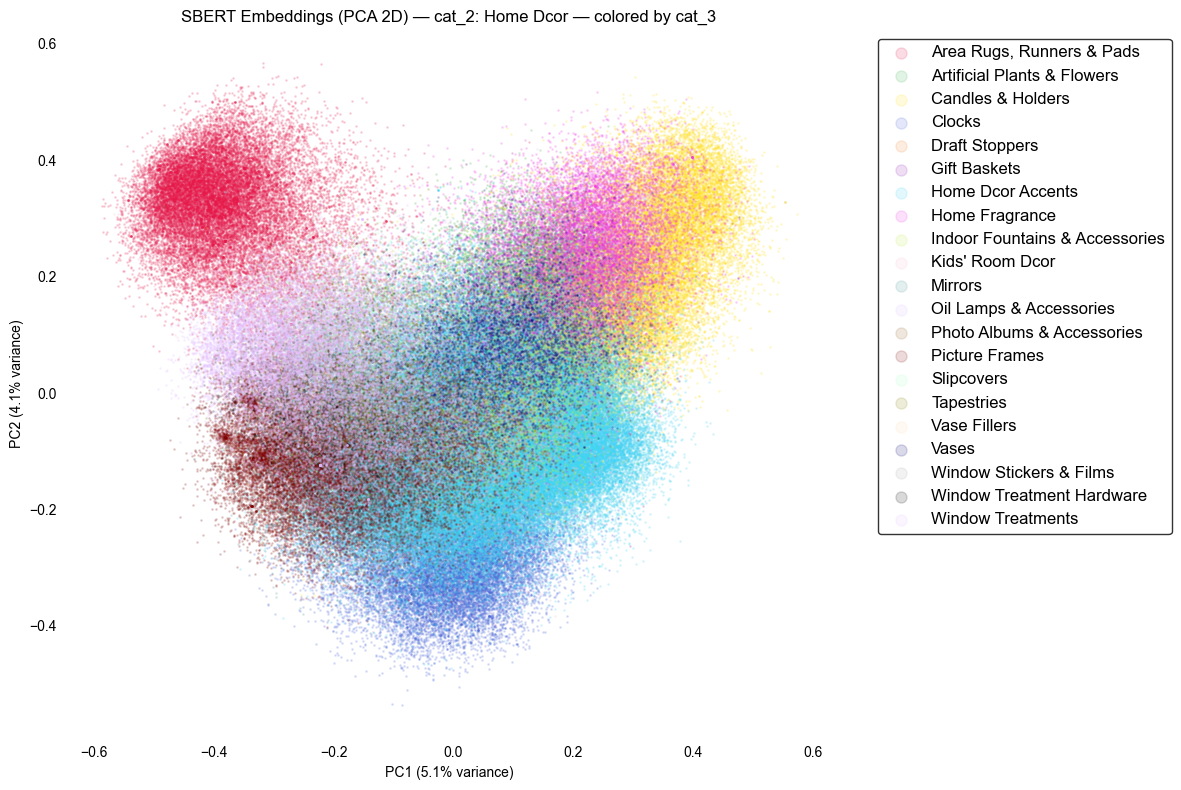

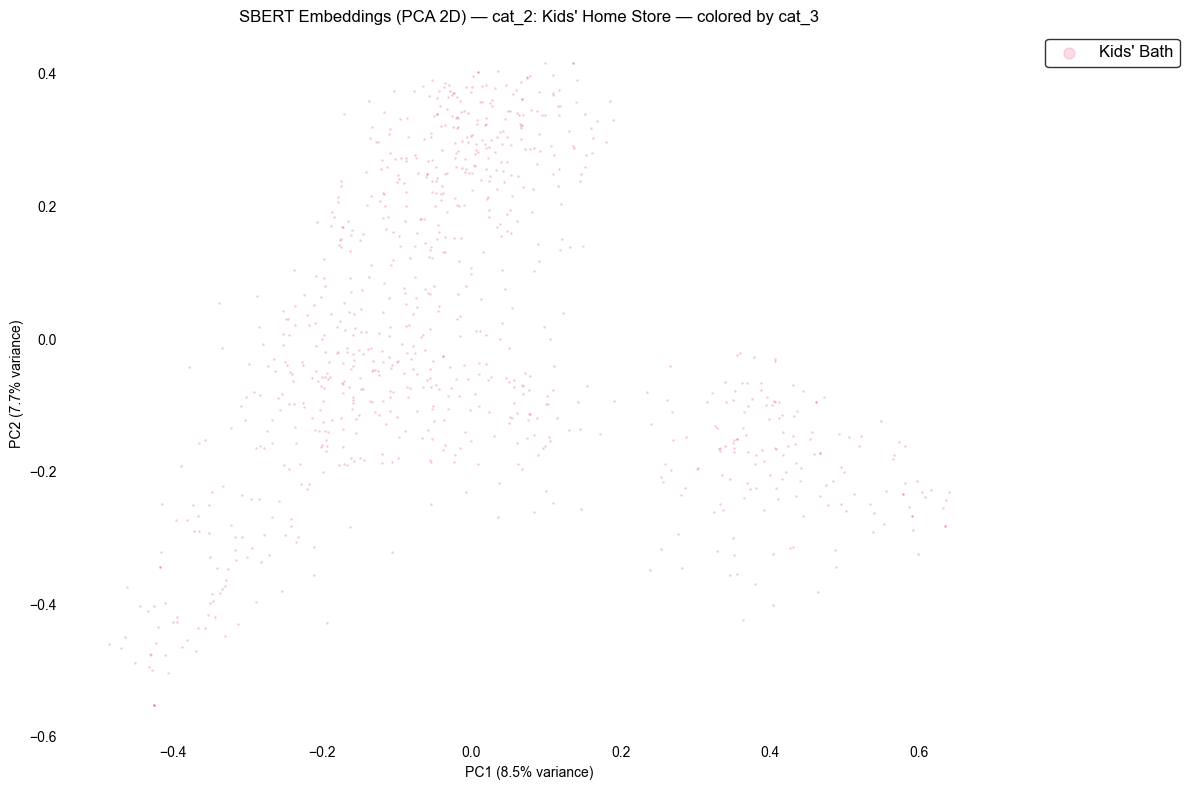

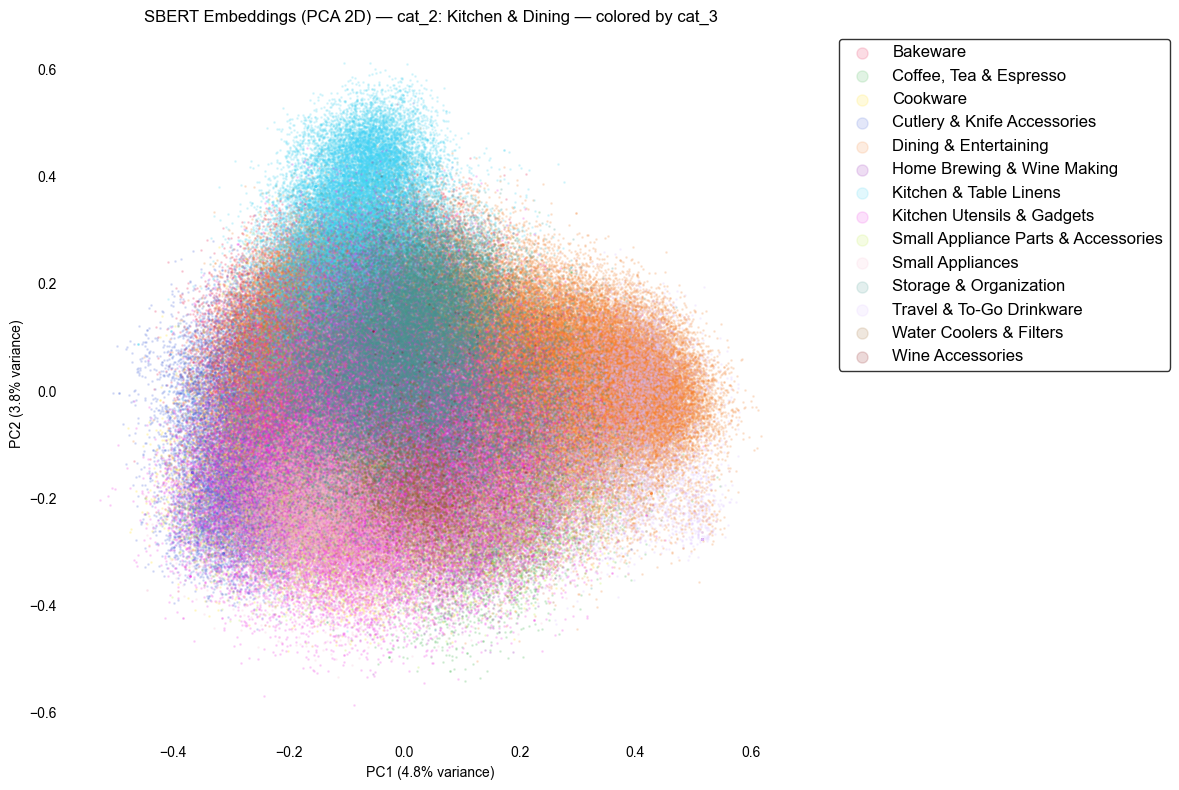

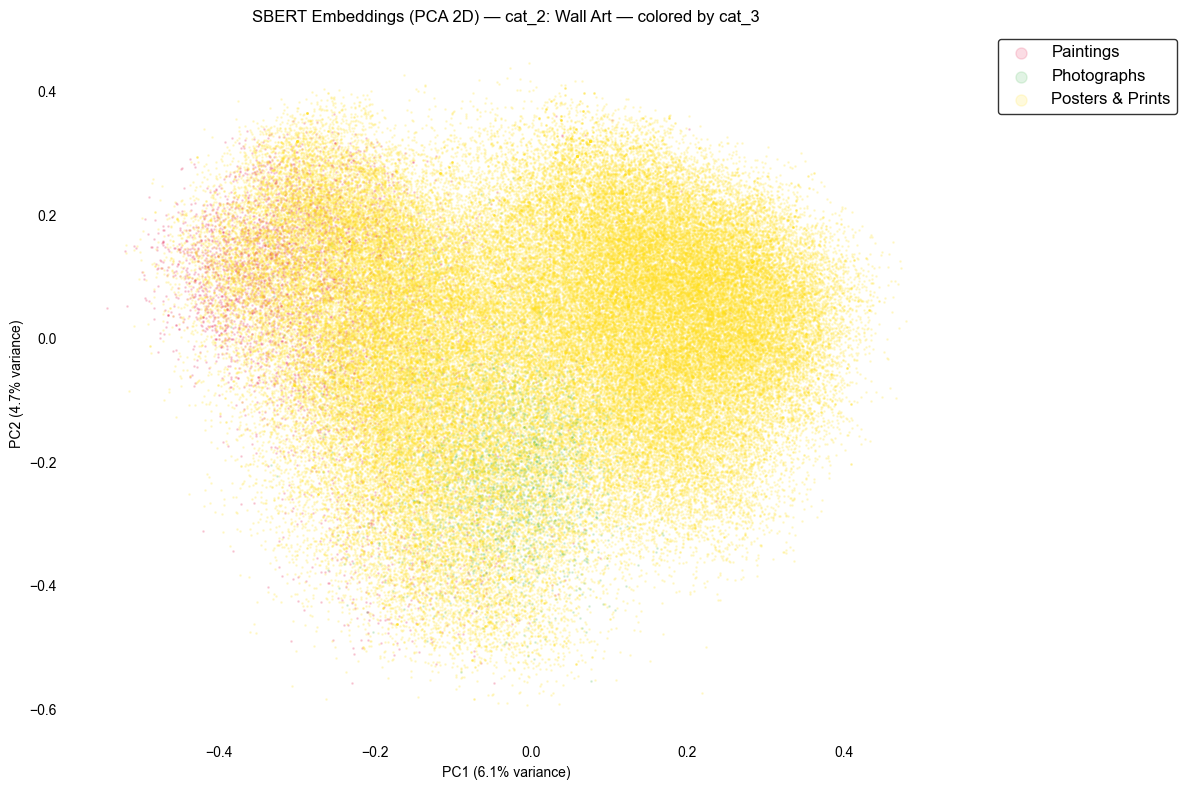

In [19]:
# 6.2 One PCA scatter per cat_2 value, colored by cat_3
visualize_pca_per_cat2(matrix, df_emb)